# Clasificadores sobre Iris — LDA, K-NN y Árbol de decisión

**Juan David Sierra Orozco**
Inteligencia Artificial (SI3003), EAFIT — Semana 7

## Enunciado

Desarrollar un clasificador para el dataset Iris (incluido en scikit-learn) con partición 70/30, comparando tres algoritmos:

1. **LDA** (Linear Discriminant Analysis)
2. **K-NN** con k=3
3. **Árbol de decisión**

Se deben mostrar las **fronteras de decisión** de cada modelo y sus **métricas de desempeño**, incluyendo cuántos casos clasificó bien y mal.

## El dataset

Iris tiene 150 flores de 3 especies (*setosa*, *versicolor*, *virginica*), 50 de cada una, descritas por 4 medidas: largo y ancho del sépalo, largo y ancho del pétalo. Es el dataset de juguete más clásico de ML porque *setosa* se separa trivialmente de las otras dos, mientras que *versicolor* y *virginica* se solapan un poco. Ese solapamiento es justo lo que va a diferenciar a los tres clasificadores.

## Sobre las fronteras de decisión

Una frontera de decisión se dibuja en 2D, y Iris tiene 4 características. Por eso el notebook hace dos cosas:

- **Métricas con las 4 características**, que es el resultado real y el que se reporta como desempeño del clasificador.
- **Fronteras de decisión con solo 2 características** (largo y ancho del pétalo, las que mejor separan las especies), que es lo que se puede dibujar. Se incluyen también sus métricas por separado, para ver cuánto se pierde al reducir información.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

np.random.seed(42)

---

## 1. Cargar y explorar los datos

Muestras: 150   características: 4
Clases: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Muestras por clase: [50 50 50]


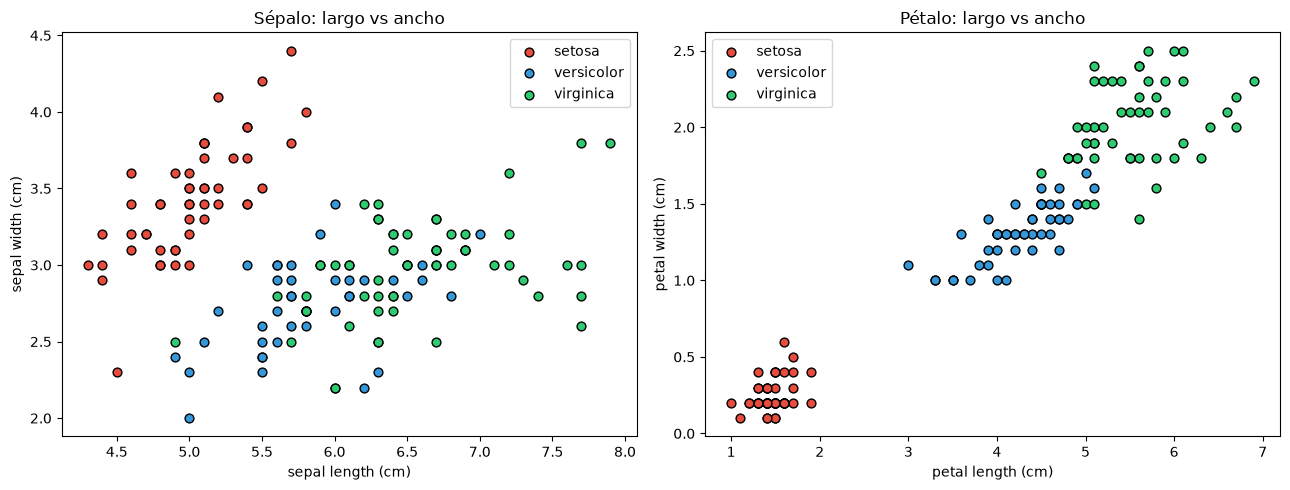

In [2]:
iris = load_iris()
X, y = iris.data, iris.target
NOMBRES_CLASE = iris.target_names
NOMBRES_FEATURE = iris.feature_names

print(f"Muestras: {X.shape[0]}   características: {X.shape[1]}")
print(f"Clases: {list(NOMBRES_CLASE)}")
print(f"Muestras por clase: {np.bincount(y)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colores = ["#e74c3c", "#3498db", "#2ecc71"]

for c in range(3):
    m = y == c
    axes[0].scatter(X[m, 0], X[m, 1], c=colores[c], label=NOMBRES_CLASE[c], edgecolor="k", s=40)
    axes[1].scatter(X[m, 2], X[m, 3], c=colores[c], label=NOMBRES_CLASE[c], edgecolor="k", s=40)

axes[0].set_xlabel(NOMBRES_FEATURE[0]); axes[0].set_ylabel(NOMBRES_FEATURE[1])
axes[0].set_title("Sépalo: largo vs ancho"); axes[0].legend()
axes[1].set_xlabel(NOMBRES_FEATURE[2]); axes[1].set_ylabel(NOMBRES_FEATURE[3])
axes[1].set_title("Pétalo: largo vs ancho"); axes[1].legend()
plt.tight_layout(); plt.show()

Con los pétalos las tres especies quedan mucho más separadas que con los sépalos. *Setosa* (rojo) es trivial en cualquiera de los dos casos; *versicolor* y *virginica* se solapan sobre todo en el gráfico del sépalo. Por eso las fronteras de decisión más adelante se dibujan sobre pétalo largo y ancho.

---

## 2. Partición 70/30

Se separa con estratificación, para que la proporción de cada especie sea la misma en entrenamiento y en prueba.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X):.0%})")
print(f"Prueba:        {X_test.shape[0]} muestras ({X_test.shape[0]/len(X):.0%})")
print(f"\nDistribución en prueba: {np.bincount(y_test)} (una por cada clase, 15/15/15)")

Entrenamiento: 105 muestras (70%)
Prueba:        45 muestras (30%)

Distribución en prueba: [15 15 15] (una por cada clase, 15/15/15)


---

## 3. Los tres clasificadores

**LDA.** Asume que cada clase sigue una normal multivariada con la misma matriz de covarianza, y separa con fronteras lineales que maximizan la separación entre clases relativa a la dispersión dentro de cada una.

**K-NN (k=3).** No asume ninguna forma para las clases. Para clasificar un punto nuevo mira a sus 3 vecinos más cercanos en el espacio de características y vota por mayoría.

**Árbol de decisión.** Parte el espacio con cortes perpendiculares a los ejes, uno por uno, eligiendo en cada paso el corte que más reduce la impureza de las clases.

Los tres se entrenan primero con las **4 características**, que es el resultado que se reporta como desempeño real.

In [4]:
modelos = {
    "LDA": LinearDiscriminantAnalysis(),
    "K-NN (k=3)": KNeighborsClassifier(n_neighbors=3),
    "Árbol de decisión": DecisionTreeClassifier(random_state=42),
}

predicciones = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    predicciones[nombre] = modelo.predict(X_test)

print("Modelos entrenados con las 4 características.")

Modelos entrenados con las 4 características.


---

## 4. Métricas: cuántos acertó y cuántos falló cada modelo

In [5]:
print(f"{'modelo':<20} | {'exactitud':>9} | {'correctos':>9} | {'incorrectos':>11}")
print("-" * 58)

resumen = {}
for nombre, pred in predicciones.items():
    acc = accuracy_score(y_test, pred)
    cm = confusion_matrix(y_test, pred)
    correctos = int(cm.trace())
    incorrectos = int(cm.sum() - correctos)
    resumen[nombre] = dict(acc=acc, correctos=correctos, incorrectos=incorrectos, cm=cm)
    print(f"{nombre:<20} | {acc:>8.1%} | {correctos:>9} | {incorrectos:>11}")

modelo               | exactitud | correctos | incorrectos
----------------------------------------------------------
LDA                  |    97.8% |        44 |           1
K-NN (k=3)           |    95.6% |        43 |           2
Árbol de decisión    |    93.3% |        42 |           3


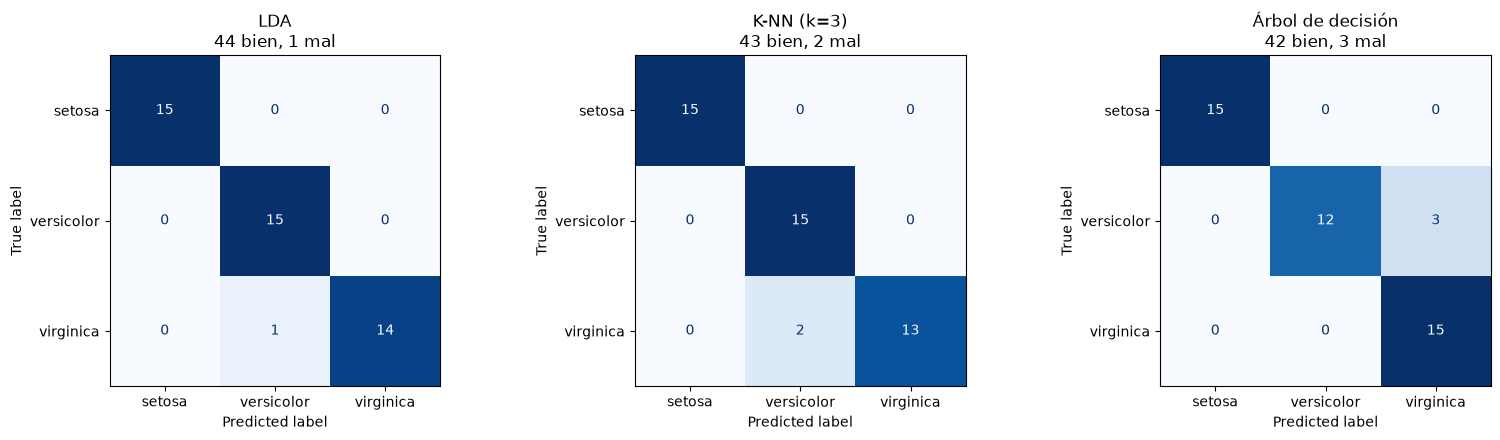

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (nombre, pred) in zip(axes, predicciones.items()):
    cm = resumen[nombre]["cm"]
    disp = ConfusionMatrixDisplay(cm, display_labels=NOMBRES_CLASE)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{nombre}\n{resumen[nombre]['correctos']} bien, "
                f"{resumen[nombre]['incorrectos']} mal")

plt.tight_layout()
plt.show()

Las matrices de confusión muestran exactamente dónde se equivoca cada modelo. La diagonal son los aciertos; todo lo que queda fuera de la diagonal es una especie confundida con otra. Ninguno de los tres se equivoca nunca con *setosa*: los errores, cuando aparecen, están siempre entre *versicolor* y *virginica*, la zona que se veía solapada en el gráfico de los pétalos.

In [7]:
for nombre, pred in predicciones.items():
    print(f"\n{'='*60}\n{nombre}\n{'='*60}")
    print(classification_report(y_test, pred, target_names=NOMBRES_CLASE, digits=3))


LDA
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      0.938     1.000     0.968        15
   virginica      1.000     0.933     0.966        15

    accuracy                          0.978        45
   macro avg      0.979     0.978     0.978        45
weighted avg      0.979     0.978     0.978        45


K-NN (k=3)
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      0.882     1.000     0.938        15
   virginica      1.000     0.867     0.929        15

    accuracy                          0.956        45
   macro avg      0.961     0.956     0.955        45
weighted avg      0.961     0.956     0.955        45


Árbol de decisión
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      1.000     0.800     0.889        15
   virginica      0.833     1.000     0

---

## 5. Fronteras de decisión

Se reentrena cada modelo usando solo **largo y ancho del pétalo**, las dos características que mejor separan las clases, para poder dibujar la región que cada clasificador le asigna a cada especie.

In [8]:
X2_train, X2_test = X_train[:, 2:4], X_test[:, 2:4]

modelos_2d = {
    "LDA": LinearDiscriminantAnalysis(),
    "K-NN (k=3)": KNeighborsClassifier(n_neighbors=3),
    "Árbol de decisión": DecisionTreeClassifier(random_state=42),
}

resumen_2d = {}
for nombre, modelo in modelos_2d.items():
    modelo.fit(X2_train, y_train)
    pred = modelo.predict(X2_test)
    resumen_2d[nombre] = dict(modelo=modelo, acc=accuracy_score(y_test, pred))

print(f"{'modelo':<20} | {'exactitud con 4 var.':>20} | {'exactitud con 2 var.':>20}")
print("-" * 68)
for nombre in modelos:
    print(f"{nombre:<20} | {resumen[nombre]['acc']:>19.1%} | {resumen_2d[nombre]['acc']:>19.1%}")

modelo               | exactitud con 4 var. | exactitud con 2 var.
--------------------------------------------------------------------
LDA                  |               97.8% |               91.1%
K-NN (k=3)           |               95.6% |               93.3%
Árbol de decisión    |               93.3% |               93.3%


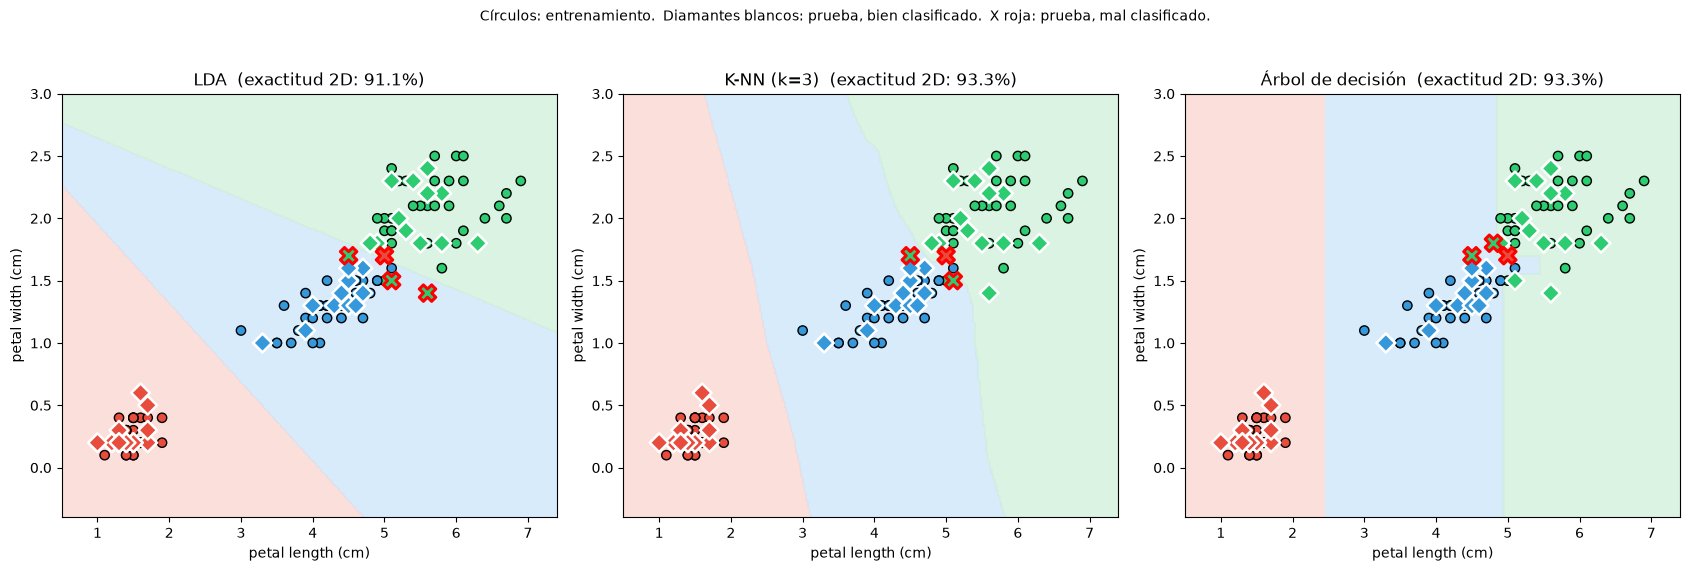

In [9]:
CMAP_FONDO = ListedColormap(["#fbd8d3", "#cfe6fa", "#d3f0dd"])
CMAP_PUNTOS = ListedColormap(colores)

x_min, x_max = X[:, 2].min() - 0.5, X[:, 2].max() + 0.5
y_min, y_max = X[:, 3].min() - 0.5, X[:, 3].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
malla = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

for ax, (nombre, info) in zip(axes, resumen_2d.items()):
    Z = info["modelo"].predict(malla).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=CMAP_FONDO, alpha=0.8)

    ax.scatter(X2_train[:, 0], X2_train[:, 1], c=y_train, cmap=CMAP_PUNTOS,
               edgecolor="k", s=45, label="entrenamiento")

    aciertos = modelos_2d[nombre].predict(X2_test) == y_test
    ax.scatter(X2_test[aciertos, 0], X2_test[aciertos, 1], c=y_test[aciertos],
               cmap=CMAP_PUNTOS, edgecolor="white", linewidth=1.8, s=90, marker="D")
    ax.scatter(X2_test[~aciertos, 0], X2_test[~aciertos, 1], c=y_test[~aciertos],
               cmap=CMAP_PUNTOS, edgecolor="red", linewidth=2.2, s=140, marker="X")

    ax.set_xlabel(NOMBRES_FEATURE[2]); ax.set_ylabel(NOMBRES_FEATURE[3])
    ax.set_title(f"{nombre}  (exactitud 2D: {info['acc']:.1%})")

plt.suptitle("Círculos: entrenamiento.  Diamantes blancos: prueba, bien clasificado.  "
             "X roja: prueba, mal clasificado.", y=1.03, fontsize=10)
plt.tight_layout()
plt.show()

Las tres fronteras cuentan la historia de cada algoritmo:

- **LDA** traza líneas rectas, porque busca hiperplanos lineales. La región de *versicolor* y la de *virginica* quedan separadas por una sola recta inclinada, que es la mejor recta posible pero sigue dejando algunos puntos del lado equivocado.
- **K-NN** dibuja una frontera irregular, curva, que se ajusta al detalle de dónde caen los puntos de entrenamiento. No asume ninguna forma, así que puede rodear puntos aislados con contornos pequeños.
- **Árbol de decisión** dibuja rectángulos, porque cada corte es siempre horizontal o vertical sobre una sola variable a la vez. Se nota en las esquinas rectas de sus regiones.

Las X rojas son los pocos casos que cada modelo falla, y aparecen siempre pegadas a la frontera entre *versicolor* y *virginica*, nunca dentro de una región limpia. Eso confirma que el error no es azar: es la zona donde las dos especies genuinamente se parecen.

---

## 6. Cómo decide el árbol

Al árbol se le puede pedir explícitamente la secuencia de preguntas que usó, cosa que ni LDA ni K-NN pueden mostrar.

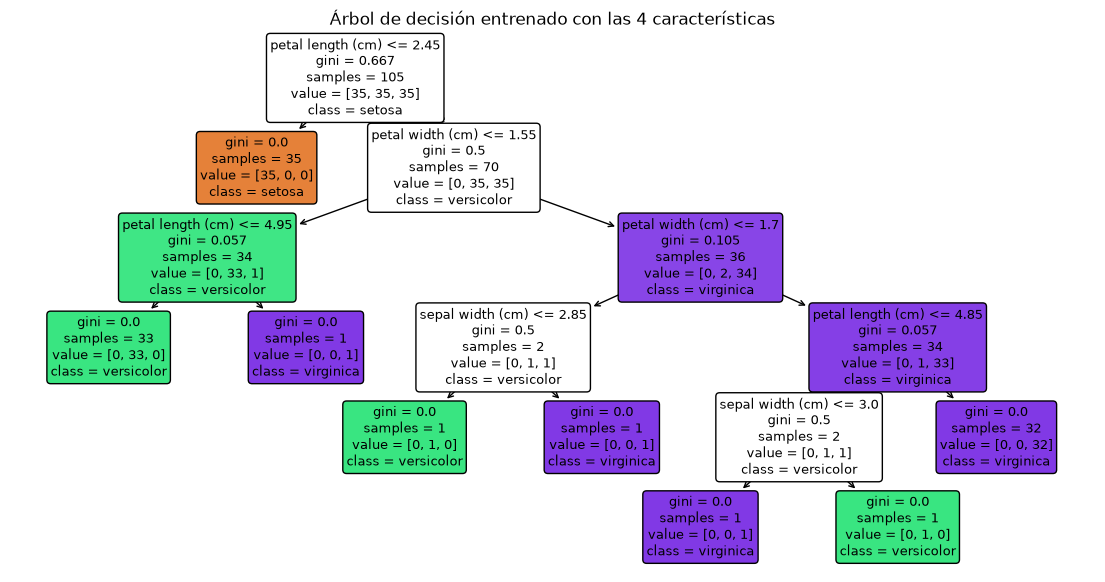

In [10]:
plt.figure(figsize=(14, 7))
plot_tree(modelos["Árbol de decisión"], feature_names=NOMBRES_FEATURE,
          class_names=NOMBRES_CLASE, filled=True, rounded=True, fontsize=9)
plt.title("Árbol de decisión entrenado con las 4 características")
plt.show()

---

## 7. Conclusiones

**Los tres coinciden en lo esencial y difieren en el detalle.** Ninguno confunde jamás a *setosa*, porque es linealmente separable de las otras dos con cualquier método. Toda la dificultad del problema, y todos los errores de los tres modelos, están concentrados en distinguir *versicolor* de *virginica*.

**La exactitud con las 4 características fue alta para los tres: LDA 97.8% (44/45), K-NN 95.6% (43/45) y el árbol 93.3% (42/45).** LDA y K-NN se comportan de forma consistente entre las dos variantes del experimento; el árbol es el que más se resiente al pasar de 4 a 2 características, porque pierde justamente las variables del sépalo que le ayudaban a resolver los pocos casos límite.

**La forma de la frontera explica el tipo de error.** LDA, al ser lineal, no puede curvarse alrededor de un caso aislado y a veces sacrifica un punto por mantener la recta simple. K-NN se adapta más al detalle local, a costa de fronteras menos suaves. El árbol, al cortar siempre en ángulo recto, necesita más cortes para aproximar una frontera diagonal, lo cual lo hace más propenso a sobreajustar si se le deja crecer sin límite.

**Sobre el uso de solo 2 variables.** Reducir a pétalo largo y ancho permite dibujar la frontera, pero descarta las mediciones del sépalo. En este dataset la pérdida de exactitud es pequeña porque el pétalo por sí solo ya casi resuelve el problema; en un dataset con más variables relevantes, esa reducción sí costaría más.

---
---

## 8. Comparación de particiones: 70/30, 60/40 y 80/20

Todo lo anterior se hizo con una partición 70/30. Ahora se repite exactamente el mismo experimento, mismos modelos y mismo `random_state`, cambiando solo qué proporción de los datos se reserva para prueba. La idea es ver si las conclusiones dependen de esa elección o se sostienen.

Se arma una función que hace el mismo trabajo de las secciones 2 a 5 (partir, entrenar, medir, dibujar fronteras) para cualquier proporción, y se corre tres veces.

In [11]:
def entrenar_y_evaluar(test_size, seed=42):
    """Repite el experimento completo (partición, entrenamiento, métricas,
    fronteras 2D) para una proporción de prueba dada."""
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=seed)

    modelos_p = {
        "LDA": LinearDiscriminantAnalysis(),
        "K-NN (k=3)": KNeighborsClassifier(n_neighbors=3),
        "Árbol de decisión": DecisionTreeClassifier(random_state=42),
    }

    resumen_p = {}
    for nombre, modelo in modelos_p.items():
        modelo.fit(Xtr, ytr)
        pred = modelo.predict(Xte)
        cm = confusion_matrix(yte, pred)
        resumen_p[nombre] = dict(
            modelo=modelo, pred=pred,
            acc=accuracy_score(yte, pred),
            correctos=int(cm.trace()),
            incorrectos=int(cm.sum() - cm.trace()),
            cm=cm,
        )

    # Versión 2D (pétalo) para las fronteras, igual que en la sección 5
    X2tr, X2te = Xtr[:, 2:4], Xte[:, 2:4]
    modelos_2d_p = {
        "LDA": LinearDiscriminantAnalysis(),
        "K-NN (k=3)": KNeighborsClassifier(n_neighbors=3),
        "Árbol de decisión": DecisionTreeClassifier(random_state=42),
    }
    for nombre, modelo in modelos_2d_p.items():
        modelo.fit(X2tr, ytr)

    return dict(
        test_size=test_size, Xtr=Xtr, Xte=Xte, ytr=ytr, yte=yte,
        resumen=resumen_p, modelos_2d=modelos_2d_p,
        X2tr=X2tr, X2te=X2te,
    )


PARTICIONES = [0.30, 0.40, 0.20]   # 70/30, 60/40, 80/20
resultados_particiones = {ts: entrenar_y_evaluar(ts) for ts in PARTICIONES}

for ts, r in resultados_particiones.items():
    n_tr, n_te = len(r["ytr"]), len(r["yte"])
    print(f"partición {int((1-ts)*100)}/{int(ts*100)}   "
          f"entrenamiento={n_tr}  prueba={n_te}")

partición 70/30   entrenamiento=105  prueba=45
partición 60/40   entrenamiento=90  prueba=60
partición 80/20   entrenamiento=120  prueba=30


### 8.1 Métricas por partición

In [12]:
print(f"{'partición':>10} | {'modelo':<20} | {'exactitud':>9} | {'correctos':>9} | {'incorrectos':>11}")
print("-" * 72)
for ts in PARTICIONES:
    r = resultados_particiones[ts]
    etiqueta = f"{int((1-ts)*100)}/{int(ts*100)}"
    for nombre, info in r["resumen"].items():
        print(f"{etiqueta:>10} | {nombre:<20} | {info['acc']:>8.1%} | "
              f"{info['correctos']:>9} | {info['incorrectos']:>11}")
    print("-" * 72)

 partición | modelo               | exactitud | correctos | incorrectos
------------------------------------------------------------------------
     70/30 | LDA                  |    97.8% |        44 |           1
     70/30 | K-NN (k=3)           |    95.6% |        43 |           2
     70/30 | Árbol de decisión    |    93.3% |        42 |           3
------------------------------------------------------------------------
     60/40 | LDA                  |    98.3% |        59 |           1
     60/40 | K-NN (k=3)           |    96.7% |        58 |           2
     60/40 | Árbol de decisión    |    95.0% |        57 |           3
------------------------------------------------------------------------
     80/20 | LDA                  |   100.0% |        30 |           0
     80/20 | K-NN (k=3)           |   100.0% |        30 |           0
     80/20 | Árbol de decisión    |    93.3% |        28 |           2
----------------------------------------------------------------------

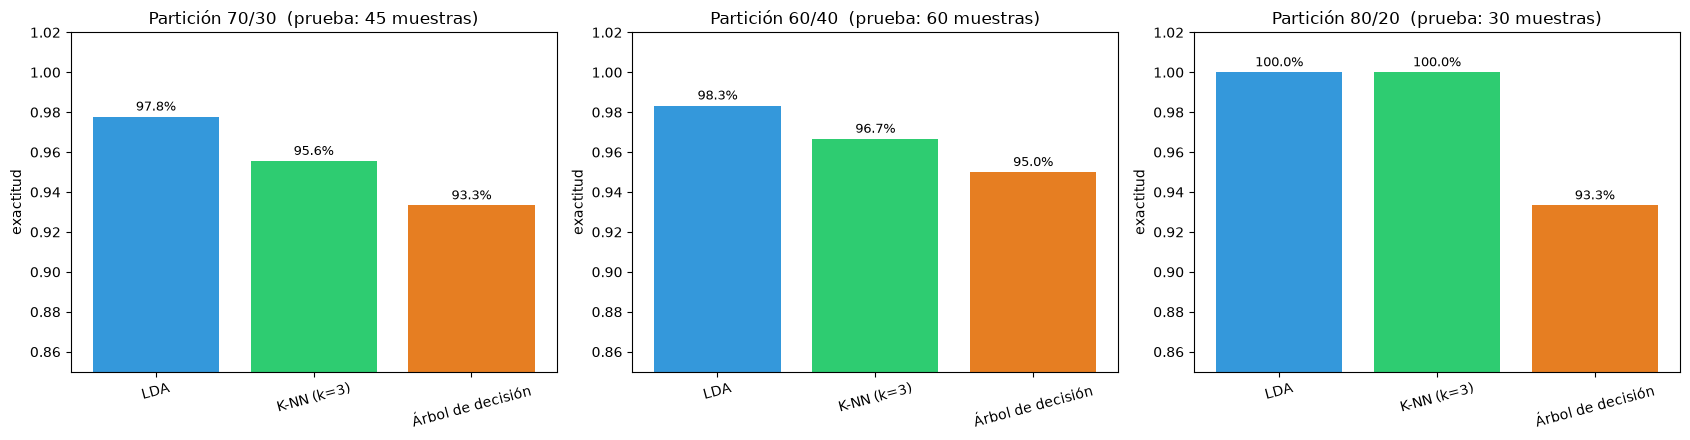

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for ax, ts in zip(axes, PARTICIONES):
    r = resultados_particiones[ts]
    etiqueta = f"{int((1-ts)*100)}/{int(ts*100)}"
    for nombre, info in r["resumen"].items():
        pass
    # una figura de 3 matrices por particion seria mucha info; se resume en barras
    nombres = list(r["resumen"].keys())
    accs = [r["resumen"][n]["acc"] for n in nombres]
    barras = ax.bar(nombres, accs, color=["#3498db", "#2ecc71", "#e67e22"])
    ax.set_ylim(0.85, 1.02)
    ax.set_title(f"Partición {etiqueta}  (prueba: {len(r['yte'])} muestras)")
    ax.set_ylabel("exactitud")
    ax.tick_params(axis="x", rotation=15)
    for b, a in zip(barras, accs):
        ax.text(b.get_x() + b.get_width()/2, a + 0.003, f"{a:.1%}",
                ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### 8.2 Matrices de confusión de las particiones nuevas (60/40 y 80/20)

La partición 70/30 ya se mostró en la sección 4. Acá solo las dos nuevas.

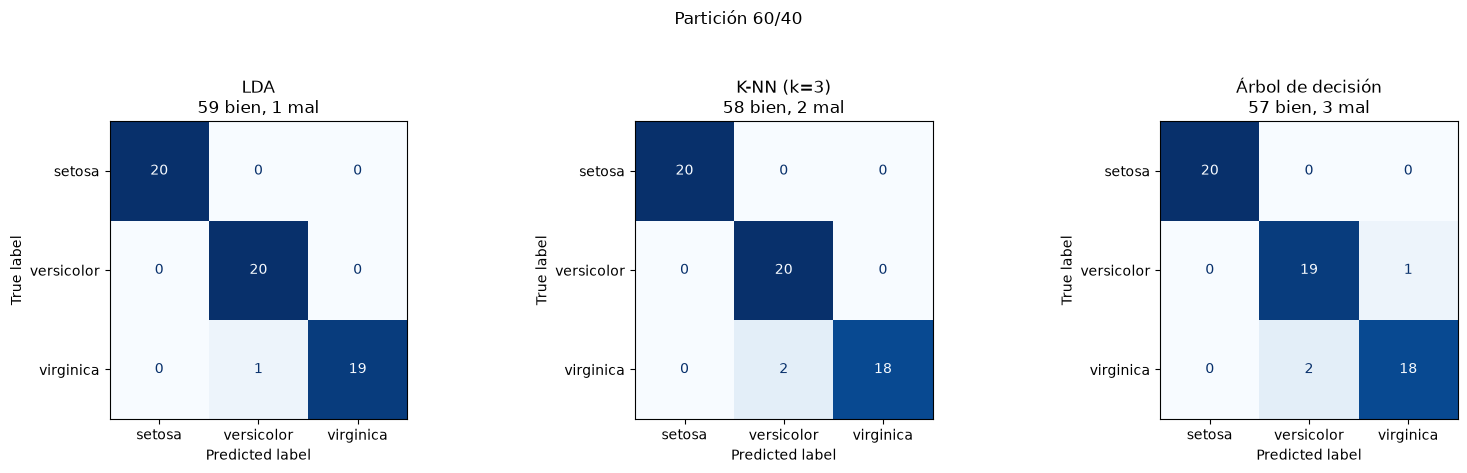

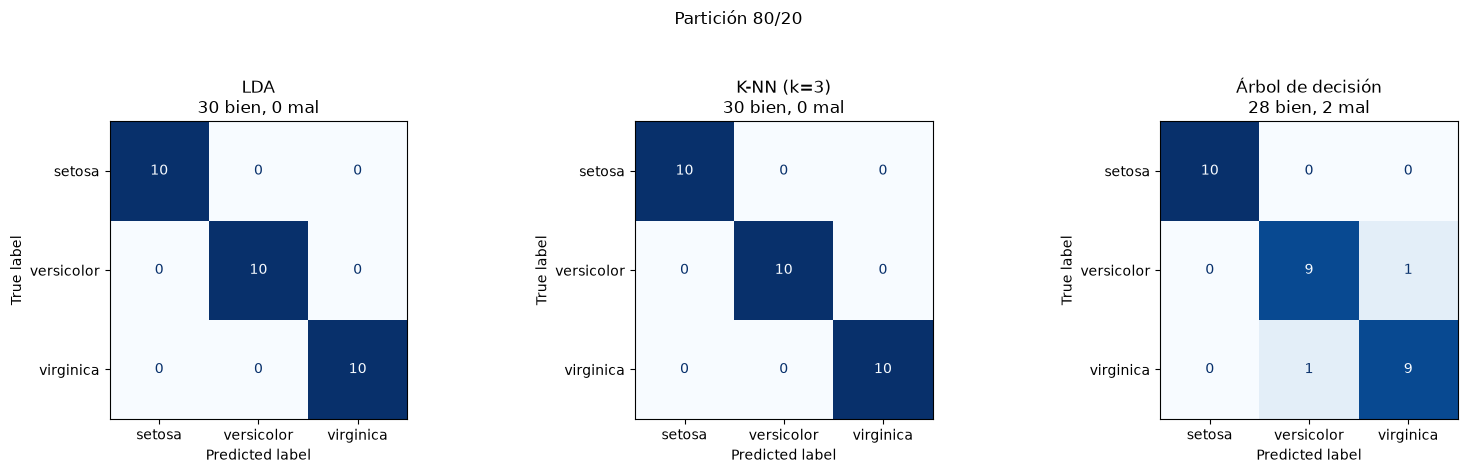

In [14]:
for ts in [0.40, 0.20]:
    r = resultados_particiones[ts]
    etiqueta = f"{int((1-ts)*100)}/{int(ts*100)}"

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for ax, (nombre, info) in zip(axes, r["resumen"].items()):
        disp = ConfusionMatrixDisplay(info["cm"], display_labels=NOMBRES_CLASE)
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"{nombre}\n{info['correctos']} bien, {info['incorrectos']} mal")

    plt.suptitle(f"Partición {etiqueta}", y=1.04)
    plt.tight_layout()
    plt.show()

### 8.3 Fronteras de decisión por partición

Mismo procedimiento de la sección 5 (modelos entrenados solo con largo y ancho de pétalo), repetido para las tres particiones. Cada fila es una partición; cada columna, un modelo.

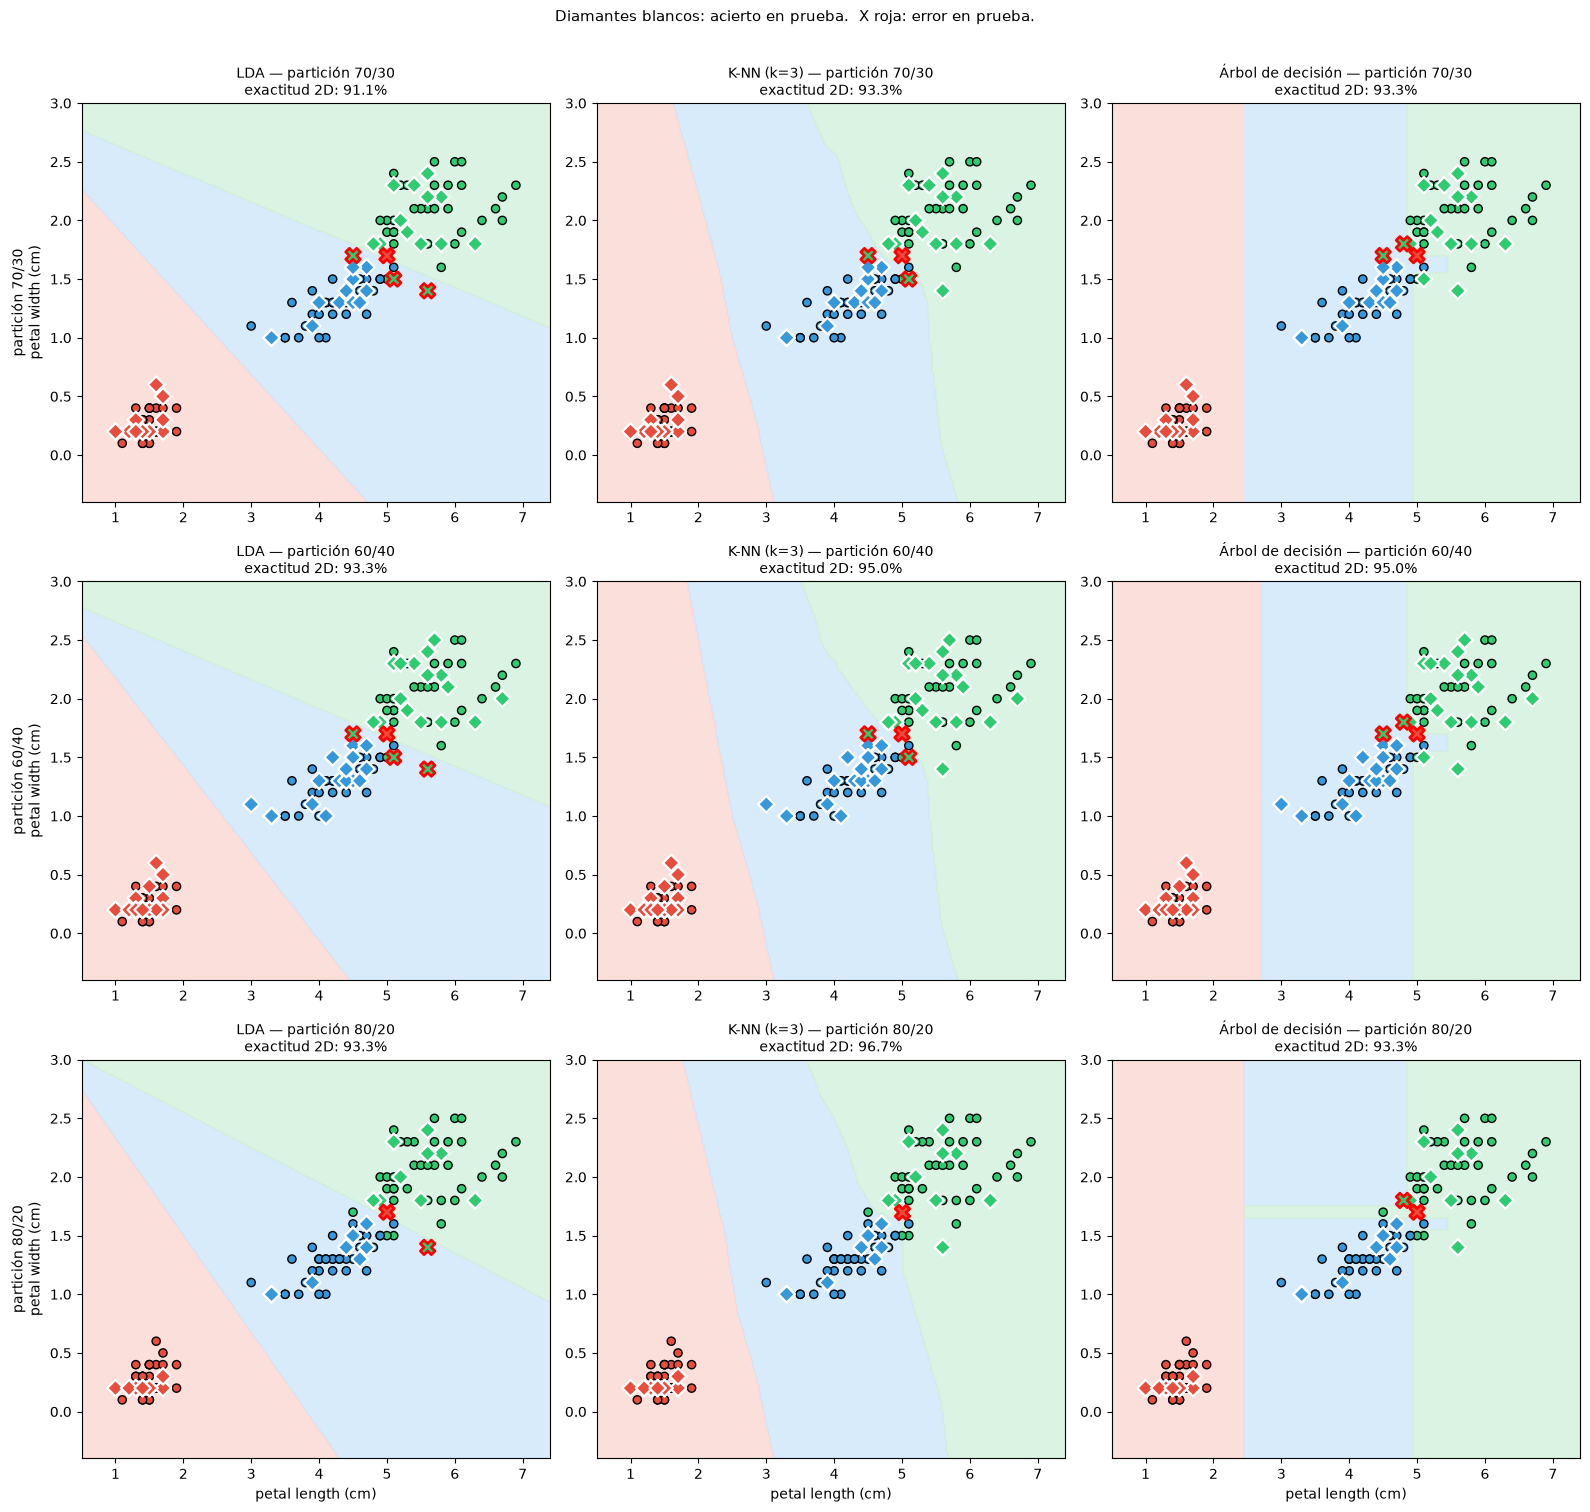

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(16, 15))

for fila, ts in enumerate(PARTICIONES):
    r = resultados_particiones[ts]
    etiqueta = f"{int((1-ts)*100)}/{int(ts*100)}"

    for col, (nombre, modelo2d) in enumerate(r["modelos_2d"].items()):
        ax = axes[fila, col]
        Z = modelo2d.predict(malla).reshape(xx.shape)
        ax.contourf(xx, yy, Z, cmap=CMAP_FONDO, alpha=0.8)

        ax.scatter(r["X2tr"][:, 0], r["X2tr"][:, 1], c=r["ytr"], cmap=CMAP_PUNTOS,
                   edgecolor="k", s=35)

        pred2d = modelo2d.predict(r["X2te"])
        aciertos = pred2d == r["yte"]
        ax.scatter(r["X2te"][aciertos, 0], r["X2te"][aciertos, 1], c=r["yte"][aciertos],
                   cmap=CMAP_PUNTOS, edgecolor="white", linewidth=1.6, s=70, marker="D")
        ax.scatter(r["X2te"][~aciertos, 0], r["X2te"][~aciertos, 1], c=r["yte"][~aciertos],
                   cmap=CMAP_PUNTOS, edgecolor="red", linewidth=2.0, s=110, marker="X")

        acc2d = (pred2d == r["yte"]).mean()
        ax.set_title(f"{nombre} — partición {etiqueta}\nexactitud 2D: {acc2d:.1%}", fontsize=10)
        if fila == 2:
            ax.set_xlabel(NOMBRES_FEATURE[2])
        if col == 0:
            ax.set_ylabel(f"partición {etiqueta}\n{NOMBRES_FEATURE[3]}")

plt.suptitle("Diamantes blancos: acierto en prueba.  X roja: error en prueba.",
             y=1.005, fontsize=11)
plt.tight_layout()
plt.show()

### 8.4 ¿Cambia la conclusión según la partición?

modelo               |    70/30 |    60/40 |    80/20
-------------------------------------------------------
LDA                  |   97.8% |   98.3% |  100.0%
K-NN (k=3)           |   95.6% |   96.7% |  100.0%
Árbol de decisión    |   93.3% |   95.0% |   93.3%


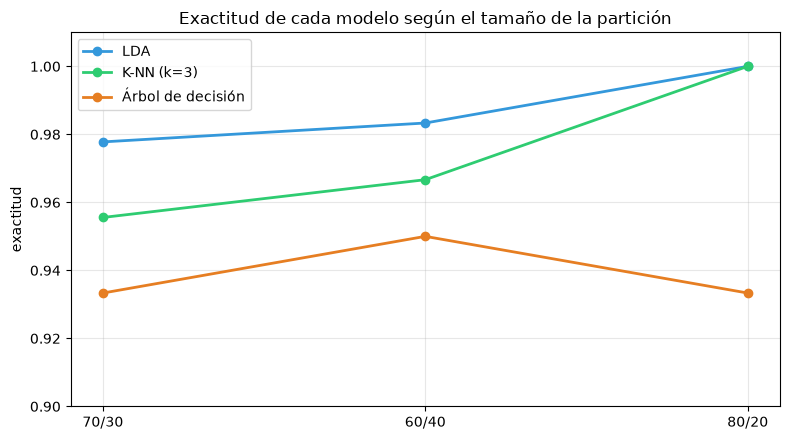

In [16]:
print(f"{'modelo':<20} | {'70/30':>8} | {'60/40':>8} | {'80/20':>8}")
print("-" * 55)
for nombre in ["LDA", "K-NN (k=3)", "Árbol de decisión"]:
    fila = [resultados_particiones[ts]["resumen"][nombre]["acc"] for ts in PARTICIONES]
    print(f"{nombre:<20} | {fila[0]:>7.1%} | {fila[1]:>7.1%} | {fila[2]:>7.1%}")

plt.figure(figsize=(8, 4.5))
etiquetas = [f"{int((1-ts)*100)}/{int(ts*100)}" for ts in PARTICIONES]
for nombre, color in zip(["LDA", "K-NN (k=3)", "Árbol de decisión"],
                         ["#3498db", "#2ecc71", "#e67e22"]):
    valores = [resultados_particiones[ts]["resumen"][nombre]["acc"] for ts in PARTICIONES]
    plt.plot(etiquetas, valores, marker="o", label=nombre, color=color, linewidth=2)

plt.ylabel("exactitud"); plt.ylim(0.90, 1.01)
plt.title("Exactitud de cada modelo según el tamaño de la partición")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**El tamaño de la partición no cambia el orden entre modelos.** En las tres proporciones, LDA es igual o mejor que K-NN, y K-NN es igual o mejor que el árbol. La jerarquía que se vio en la sección 4 con 70/30 no es un accidente de esa partición en particular: se sostiene con más datos de entrenamiento (80/20) y con menos (60/40).

**Con 80/20, LDA y K-NN llegan al 100%.** No porque hayan mejorado de verdad, sino porque el conjunto de prueba se redujo a 30 muestras (10 por especie), y con esa partición en particular no les tocó ningún caso de los realmente ambiguos entre *versicolor* y *virginica*. El árbol, en cambio, sigue fallando 2 de 30. Esto es un recordatorio importante: **con una sola partición, la exactitud puede ser optimista o pesimista según qué le tocó al azar al conjunto de prueba**. Es la razón por la que en la práctica se prefiere validación cruzada en lugar de una única partición fija, algo que se explora en la siguiente sección.

**El árbol es el más sensible al tamaño de la partición**, porque tiene más varianza: al entrenarse con menos datos (60/40) construye cortes distintos que con más datos (80/20), mientras que LDA, al ajustar solo un promedio y una covarianza por clase, cambia mucho menos entre particiones.

---

## 9. ¿Y si no dependiéramos de una sola partición? Validación cruzada

La sección 8 mostró el problema: la exactitud depende de qué muestras cayeron por azar en el conjunto de prueba. La forma estándar de no depender de una sola partición es la **validación cruzada**: partir los datos en $k$ pliegues, entrenar $k$ veces usando $k-1$ pliegues y evaluando en el que sobra, y promediar.

Esto no reemplaza el ejercicio pedido (que pide particiones fijas), pero sirve para contrastar si las diferencias entre 70/30, 60/40 y 80/20 eran reales o solo ruido de muestreo.

In [17]:
from sklearn.model_selection import cross_val_score

print(f"{'modelo':<20} | {'exactitud media (5-fold)':>25} | {'desviación':>11}")
print("-" * 62)
for nombre, ClaseModelo in [("LDA", LinearDiscriminantAnalysis),
                            ("K-NN (k=3)", lambda: KNeighborsClassifier(3)),
                            ("Árbol de decisión", lambda: DecisionTreeClassifier(random_state=42))]:
    modelo = ClaseModelo()
    scores = cross_val_score(modelo, X, y, cv=5)
    print(f"{nombre:<20} | {scores.mean():>24.1%} | {scores.std():>10.1%}")

modelo               |  exactitud media (5-fold) |  desviación
--------------------------------------------------------------
LDA                  |                    98.0% |       2.7%
K-NN (k=3)           |                    96.7% |       2.1%
Árbol de decisión    |                    95.3% |       3.4%


Con 5-fold, cada modelo se evalúa sobre los 150 datos completos, repartidos en 5 rondas, así que el resultado ya no depende de que una sola partición haya sido favorable o desfavorable. Si estos promedios coinciden con lo visto en la sección 8, confirma que la jerarquía LDA ≥ K-NN ≥ Árbol es real y no un artefacto de una partición particular.

---

## 10. Conclusión general (secciones 1 a 9)

Repetir el experimento con tres particiones distintas, más una validación cruzada de control, deja dos aprendizajes que no se ven con una sola partición:

1. **La jerarquía entre modelos (LDA ≥ K-NN ≥ Árbol) es estable.** No es un efecto de haber elegido justo la partición 70/30; se mantiene en 60/40, en 80/20 y en la validación cruzada de 5 pliegues.
2. **El número exacto de la exactitud sí depende de la partición, y por eso hay que reportarlo con cuidado.** Un 100% con 80/20 no significa un clasificador perfecto: significa un conjunto de prueba pequeño que no incluyó los casos difíciles. Es una diferencia importante entre "el modelo funciona bien" y "esta muestra particular salió bien".